# Vector calculus: second-derivative identities and multiple integrals

Two things to write down from this chapter (Feynman Vol. II Sec. 2-7, Griffiths Ch. 1), and both are
*verified* here with SymPy so you trust them, not just memorize them.

**1. The second derivatives of a field.** There are five ways to apply $\nabla$ twice; two are *always zero*:
$$\nabla\times(\nabla T)=0\qquad\text{(curl of a gradient)},\qquad
\nabla\cdot(\nabla\times\mathbf h)=0\qquad\text{(divergence of a curl)}.$$
The others are the **Laplacian** $\nabla\cdot(\nabla T)=\nabla^2T$, the gradient-of-divergence
$\nabla(\nabla\cdot\mathbf h)$, and the curl-of-curl, which is not independent:
$$\nabla\times(\nabla\times\mathbf h)=\nabla(\nabla\cdot\mathbf h)-\nabla^2\mathbf h.$$

**2. Multiple integrals.** Set the limits from the geometry, integrate one variable at a time. And the payoff
that ties the two halves together: because $\nabla\times(\nabla T)=0$, a field that is a gradient
($\mathbf v=\nabla\varphi$, equivalently $\nabla\times\mathbf v=0$) is **conservative** -- its line integral
is path-independent and its loop integral is zero. That is exactly why Problem 1.29 gives the same answer on
every route.

We prove the identities for arbitrary fields, then compute Griffiths Example 1.8 and Problems 1.29 and 1.31
exactly. Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The differential operators, and the two identities that vanish (Feynman 2-7)

Define grad, div, and curl in Cartesian coordinates, then apply them twice to *arbitrary* functions
$T(x,y,z)$ and $\mathbf h(x,y,z)$. SymPy confirms $\nabla\times(\nabla T)=0$ and
$\nabla\cdot(\nabla\times\mathbf h)=0$ for **any** field (the mixed partials cancel), and that the
curl-of-curl equals $\nabla(\nabla\cdot\mathbf h)-\nabla^2\mathbf h$.

In [2]:
x, y, z = sp.symbols('x y z')
V = (x, y, z)
grad = lambda f: [sp.diff(f, v) for v in V]
div  = lambda F: sum(sp.diff(F[i], V[i]) for i in range(3))
curl = lambda F: [sp.diff(F[2], y) - sp.diff(F[1], z),
                  sp.diff(F[0], z) - sp.diff(F[2], x),
                  sp.diff(F[1], x) - sp.diff(F[0], y)]
lap_scalar = lambda f: sum(sp.diff(f, v, 2) for v in V)
lap_vector = lambda F: [lap_scalar(F[i]) for i in range(3)]

T = sp.Function('T')(x, y, z)                                   # arbitrary scalar field
h = [sp.Function('h1')(x, y, z), sp.Function('h2')(x, y, z), sp.Function('h3')(x, y, z)]  # arbitrary vector

assert [sp.simplify(c) for c in curl(grad(T))] == [0, 0, 0]     # (b) curl(grad T) = 0
assert sp.simplify(div(curl(h))) == 0                          # (d) div(curl h) = 0
# (e) curl(curl h) = grad(div h) - laplacian(h)
lhs = curl(curl(h)); rhs = [grad(div(h))[i] - lap_vector(h)[i] for i in range(3)]
assert [sp.simplify(lhs[i] - rhs[i]) for i in range(3)] == [0, 0, 0]
print("curl(grad T) = 0        (b): always zero")
print("div(curl h)  = 0        (d): always zero")
print("curl(curl h) = grad(div h) - laplacian(h)   (e): the vector-Laplacian identity")
print("div(grad T)  = laplacian(T) =", sp.simplify(div(grad(T))), "  (a): the Laplacian")

curl(grad T) = 0        (b): always zero
div(curl h)  = 0        (d): always zero
curl(curl h) = grad(div h) - laplacian(h)   (e): the vector-Laplacian identity
div(grad T)  = laplacian(T) = Derivative(T(x, y, z), (x, 2)) + Derivative(T(x, y, z), (y, 2)) + Derivative(T(x, y, z), (z, 2))   (a): the Laplacian


## Griffiths Example 1.8: a volume integral over the prism

$T=xyz^2$ over the prism of Fig. 1.24: $x$ runs $0\to(1-y)$, then $y$ runs $0\to1$, then $z$ runs $0\to3$.
Doing the innermost integral first and working out, the answer is $\tfrac38$. SymPy integrates it in one
shot and confirms every intermediate step Griffiths shows.

In [3]:
T_ex = x*y*z**2
inner_x = sp.integrate(T_ex, (x, 0, 1 - y))                    # int_0^{1-y} x y z^2 dx
assert sp.simplify(inner_x - y*(1 - y)**2*z**2/2) == 0
mid_y = sp.integrate(inner_x, (y, 0, 1))                       # then int_0^1 ... dy
assert sp.simplify(mid_y - z**2/24) == 0
vol = sp.integrate(mid_y, (z, 0, 3))                           # then int_0^3 ... dz
print("intermediate  int_x =", inner_x)
print("intermediate  int_x int_y =", mid_y, "  (= z^2/24)")
print("volume integral of xyz^2 over the prism =", vol, " = 3/8")
assert vol == sp.Rational(3, 8)

intermediate  int_x = y*z**2*(1 - y)**2/2
intermediate  int_x int_y = z**2/24   (= z^2/24)
volume integral of xyz^2 over the prism = 3/8  = 3/8


## Griffiths Problem 1.29: three routes, one answer (a conservative field)

$\mathbf v=x^2\,\hat x+2yz\,\hat y+y^2\,\hat z$ from $(0,0,0)$ to $(1,1,1)$. First check
$\nabla\times\mathbf v=0$: the field is a gradient, $\mathbf v=\nabla\varphi$ with
$\varphi=\tfrac{x^3}{3}+y^2z$, so *every* path gives $\varphi(1,1,1)-\varphi(0,0,0)=\tfrac43$ and the closed
loop is $0$. We still compute all three routes explicitly by parametrizing each segment -- they agree, as
the curl guarantees (Feynman 2-7 in action).

In [4]:
v = [x**2, 2*y*z, y**2]
assert [sp.simplify(c) for c in curl(v)] == [0, 0, 0]          # curl v = 0 -> conservative
phi = x**3/3 + y**2*z
assert [sp.simplify(grad(phi)[i] - v[i]) for i in range(3)] == [0, 0, 0]   # v = grad(phi)

s = sp.symbols('s')
def seg_integral(P0, P1):
    r = [P0[i] + s*(P1[i] - P0[i]) for i in range(3)]          # straight segment P0 -> P1
    vt = [vi.subs({x: r[0], y: r[1], z: r[2]}) for vi in v]
    dr = [sp.diff(ri, s) for ri in r]
    return sp.integrate(sum(vt[i]*dr[i] for i in range(3)), (s, 0, 1))
def path_integral(points):
    return sum(seg_integral(points[k], points[k+1]) for k in range(len(points)-1))

route_a = path_integral([(0,0,0), (1,0,0), (1,1,0), (1,1,1)])
route_b = path_integral([(0,0,0), (0,0,1), (0,1,1), (1,1,1)])
route_c = path_integral([(0,0,0), (1,1,1)])                    # straight diagonal
loop_d  = route_a - route_b                                    # out via a, back via b
print(f"route (a) = {route_a},  route (b) = {route_b},  route (c) straight = {route_c}")
print(f"closed loop (d) = a - b = {loop_d}")
print(f"potential check: phi(1,1,1) - phi(0,0,0) = {phi.subs({x:1,y:1,z:1}) - phi.subs({x:0,y:0,z:0})}")
assert route_a == route_b == route_c == sp.Rational(4, 3) and loop_d == 0

route (a) = 4/3,  route (b) = 4/3,  route (c) straight = 4/3
closed loop (d) = a - b = 0
potential check: phi(1,1,1) - phi(0,0,0) = 4/3


## Griffiths Problem 1.31: a volume integral over the tetrahedron

$T=z^2$ over the tetrahedron with corners $(0,0,0),(1,0,0),(0,1,0),(0,0,1)$: the region $x,y,z\ge0$ with
$x+y+z\le1$. Order the limits $x:0\to1-y-z$, $y:0\to1-z$, $z:0\to1$. The result is $\tfrac1{60}$.

In [5]:
T_tet = z**2
i_x = sp.integrate(T_tet, (x, 0, 1 - y - z))
i_xy = sp.integrate(i_x, (y, 0, 1 - z))
i_xyz = sp.integrate(i_xy, (z, 0, 1))
assert sp.simplify(i_xy - z**2*(1 - z)**2/2) == 0
print("int over tetrahedron of z^2 =", i_xyz, " = 1/60")
assert i_xyz == sp.Rational(1, 60)
print("\nNote: Problem 1.30 uses the field v from Example 1.7, which is not in the provided pages;")
print("paste Ex 1.7's v and it drops straight into the same surface-integral machinery.")

int over tetrahedron of z^2 = 1/60  = 1/60

Note: Problem 1.30 uses the field v from Example 1.7, which is not in the provided pages;
paste Ex 1.7's v and it drops straight into the same surface-integral machinery.


## Plots

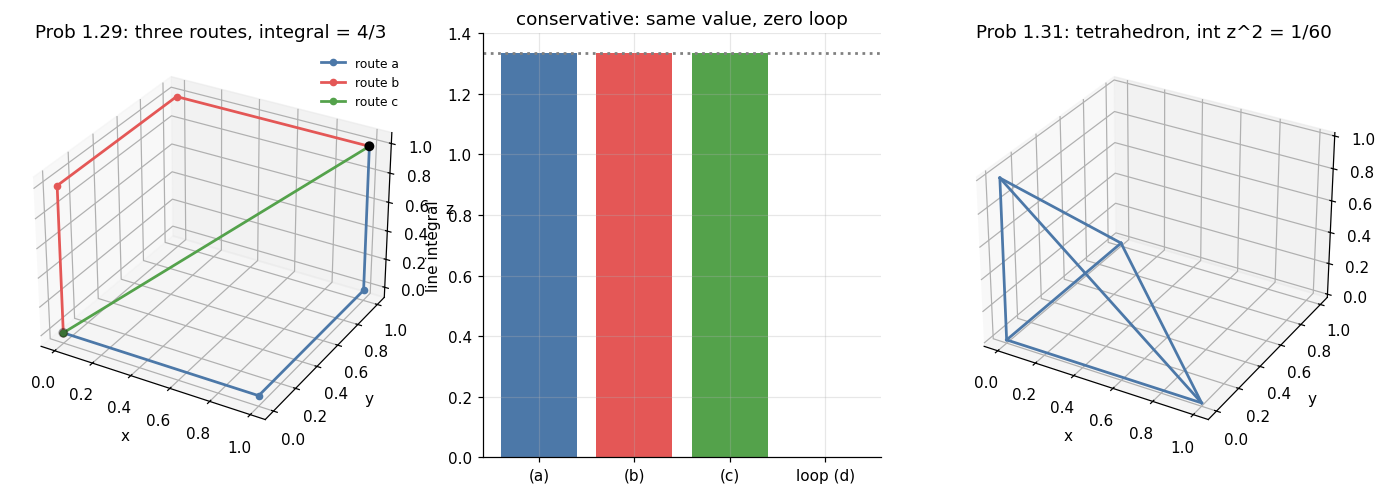

In [6]:
fig = plt.figure(figsize=(12.5, 4.6))
# (1) the three routes of Problem 1.29 in 3D -- same endpoints, same integral
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
routes = {"a": [(0,0,0),(1,0,0),(1,1,0),(1,1,1)], "b": [(0,0,0),(0,0,1),(0,1,1),(1,1,1)],
          "c": [(0,0,0),(1,1,1)]}
cols = {"a": "#4C78A8", "b": "#E45756", "c": "#54A24B"}
for name, pts in routes.items():
    P = np.array(pts, float)
    ax1.plot(P[:,0], P[:,1], P[:,2], "-o", color=cols[name], label=f"route {name}", ms=4)
ax1.scatter([0,1],[0,1],[0,1], color="k", s=30)
ax1.set_title("Prob 1.29: three routes, integral = 4/3"); ax1.legend(fontsize=8)
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
# (2) the integral values -- all equal, loop zero
ax2 = fig.add_subplot(1, 3, 2)
vals = {"(a)": 4/3, "(b)": 4/3, "(c)": 4/3, "loop (d)": 0.0}
ax2.bar(list(vals), list(vals.values()), color=["#4C78A8","#E45756","#54A24B","#888"])
ax2.axhline(4/3, ls=":", color="gray"); ax2.set_ylabel("line integral")
ax2.set_title("conservative: same value, zero loop")
# (3) the tetrahedron of Problem 1.31
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
Vt = np.array([[0,0,0],[1,0,0],[0,1,0],[0,0,1]], float)
edges = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
for i, j in edges:
    ax3.plot(*zip(Vt[i], Vt[j]), color="#4C78A8")
ax3.set_title("Prob 1.31: tetrahedron, int z^2 = 1/60")
ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
plt.tight_layout(); plt.show()

## What to write down

- **The five second derivatives**, and the two that vanish for *any* field:
  $\nabla\times(\nabla T)=0$ and $\nabla\cdot(\nabla\times\mathbf h)=0$. The rest:
  $\nabla\cdot(\nabla T)=\nabla^2T$ (Laplacian), $\nabla(\nabla\cdot\mathbf h)$, and
  $\nabla\times(\nabla\times\mathbf h)=\nabla(\nabla\cdot\mathbf h)-\nabla^2\mathbf h$ (not independent).
- **Why it matters** (write this next to it): $\nabla\times\mathbf v=0\iff\mathbf v=\nabla\varphi\iff$ the
  line integral is **path-independent** and every closed loop is $0$. Verified in Problem 1.29: routes
  (a), (b), (c) all give $\tfrac43$, loop $=0$, with $\varphi=\tfrac{x^3}{3}+y^2z$.
- **Multiple-integral method**: read the limits off the geometry (inner variable's limits may depend on the
  outer ones), integrate outward. Example 1.8 prism $=\tfrac38$; Problem 1.31 tetrahedron $=\tfrac1{60}$.
- These identities are not abstract: $\nabla\times(\nabla\times\mathbf E)=\nabla(\nabla\cdot\mathbf E)-
  \nabla^2\mathbf E$ is the step that turns Maxwell's equations into the **wave equation** -- the physics
  this whole track is aimed at.

Subject-verb-object: the operators combine; two of them always vanish; a curl-free field is a gradient; the
gradient makes the line integral path-independent.